In [ ]:
import sys
sys.path.append('/home/carroll/Documents/')

import numpy as np
import os
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import scipy.io as scio
from scipy.signal import savgol_filter
import asdprocessor
import asd_jump_correction
from spectral.io import envi
from spectral.io.envi import read_envi_header

import pickle

os.chdir('/home/carroll/Documents/')

# %matplotlib widget

In [ ]:
# prep in situ spec + isofit inputs for calibration tarps

In [ ]:
# 2018
# black, white calibration tarps

dir_insitu = '/store/carroll/col/data/2018/insitu/'
fp = glob(os.path.join(dir_insitu, f'KBDU_*', 'Data', f'KBDU_*_Refl.dat'))[0]
wavelengths = np.genfromtxt(fp, skip_header=3)[:,0]

wl_nan = np.loadtxt('/store/carroll/col/data/2025/wl_nan.txt')

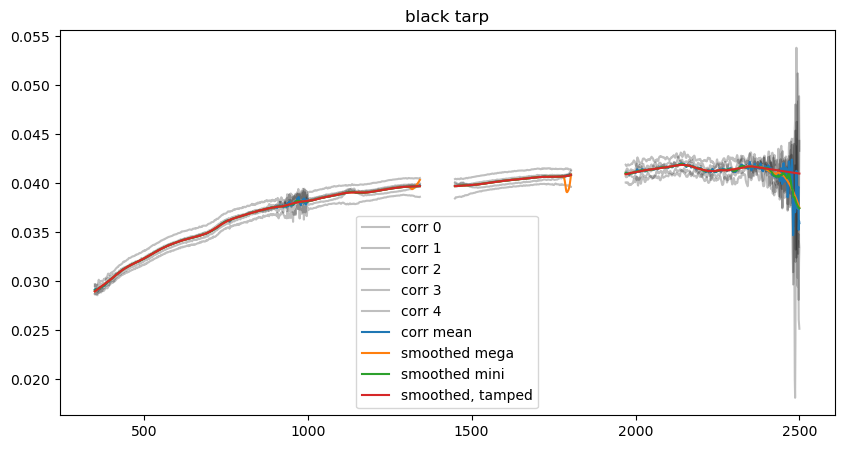

In [ ]:
# black tarp

# load raw (?) data
fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
insitu = np.empty((len(fps),wl_nan.shape[0]))
for i in range(len(fps)):
    rfl_ = np.genfromtxt(fps[i], skip_header=3)[:,1]
    insitu[i,:] = rfl_

# jump correct
insitu_jumpcorr = insitu.copy()
jump_corr_method = 'asdparabolic'
jump_corr_iterations = 3
asd_coeff_path = './correction_data/asd_temp_corr_coeffs.mat'
negatives_corr_method='parabolic'
interpolate_H2O=False,
interpolate_H2O_method='parabolic'
coeff_data = scio.loadmat(asd_coeff_path)
asd_coeffs = coeff_data['asd_temp_corr_coeffs']
for i in range(insitu.shape[0]):
    rfl_ = insitu[i,...]
    corr_output = asd_jump_correction.asd_jump_correction(asd_coeffs, rfl_, wavelengths,
                                      jump_corr_method = jump_corr_method,
                                      iterations=jump_corr_iterations,
                                      negatives_corr_method = negatives_corr_method,
                                      interpolate_H2O = interpolate_H2O,
                                      interpolate_H2O_method = interpolate_H2O_method) 
    insitu_jumpcorr[i,...] = corr_output[0] # spectrum only

rfl_mean = np.mean(insitu_jumpcorr, axis=0)

# smooth
i1280 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1280)[0]
i1450 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1450)[0]
i1750 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1750)[0]
i1970 = asd_jump_correction.get_closest_wvl_index(wavelengths, 1970)[0]
smoothed_mini = savgol_filter(rfl_mean, window_length=31, polyorder=2)
smoothed_mega = savgol_filter(rfl_mean, window_length=101, polyorder=2) # very very strong filter lol
smoothed_black = np.concatenate([smoothed_mega[0:i1280],
                                 smoothed_mini[i1280:i1450],
                                 smoothed_mega[i1450:i1750],
                                 smoothed_mini[i1750:i1970],
                                 smoothed_mega[i1970:]
                          ])


# manual corrections at swir2
swir2max = np.max(smoothed_black[wavelengths > 2300])
swir2max_idx = np.argmax((wavelengths > 2300) & (smoothed_black == swir2max))
smoothed_black[swir2max_idx:] = np.linspace(swir2max, 0.041, len(wavelengths)-swir2max_idx)

fig = plt.figure(figsize=(10,5))
for i in range(insitu_jumpcorr.shape[0]):
    rfl_corr = insitu_jumpcorr[i,...]
    plt.plot(wl_nan, rfl_corr, c='black', label=f'corr {i}', alpha=0.25)

plt.plot(wl_nan, rfl_mean, label='corr mean')

plt.plot(wl_nan, smoothed_mega, label='smoothed mega')
plt.plot(wl_nan, smoothed_mini, label='smoothed mini')
plt.plot(wl_nan, smoothed_black, label='smoothed, tamped')

plt.title('black tarp')
plt.legend()
plt.show()

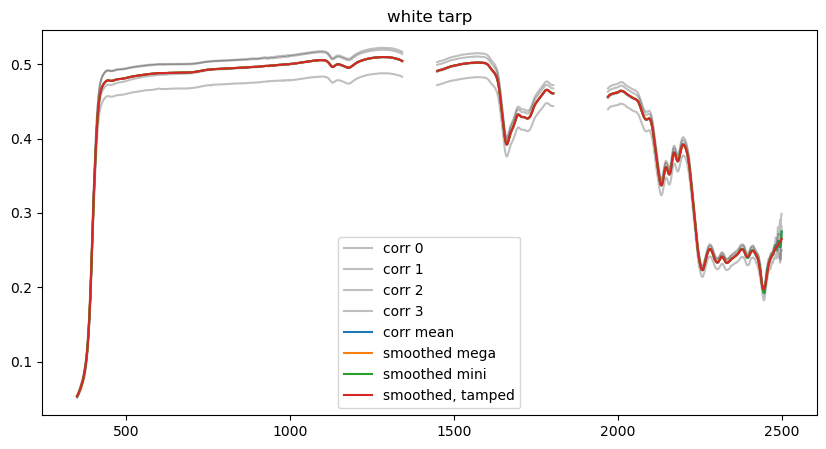

In [ ]:
# white tarp

# load raw (?) insitu rfl
fps = sorted(glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat')))
del fps[2] # drop the 2nd file as an outlier

insitu = np.empty((len(fps),wl_nan.shape[0]))
for i in range(len(fps)):
    rfl_ = np.genfromtxt(fps[i], skip_header=3)[:,1]
    insitu[i,:] = rfl_

# jump correct data using Regina's code
insitu_jumpcorr = insitu.copy()
jump_corr_method = 'asdparabolic'
jump_corr_iterations = 3
asd_coeff_path = './correction_data/asd_temp_corr_coeffs.mat'
negatives_corr_method='parabolic'
interpolate_H2O=False,
interpolate_H2O_method='parabolic'
coeff_data = scio.loadmat(asd_coeff_path)
asd_coeffs = coeff_data['asd_temp_corr_coeffs']
for i in range(insitu.shape[0]):
    rfl_ = insitu[i,...]
    corr_output = asd_jump_correction.asd_jump_correction(asd_coeffs, rfl_, wavelengths,
                                      jump_corr_method = jump_corr_method,
                                      iterations=jump_corr_iterations,
                                      negatives_corr_method = negatives_corr_method,
                                      interpolate_H2O = interpolate_H2O,
                                      interpolate_H2O_method = interpolate_H2O_method) 
    insitu_jumpcorr[i,...] = corr_output[0] # spectrum only

rfl_mean = np.mean(insitu_jumpcorr, axis=0)

# smooth
i2340 = asd_jump_correction.get_closest_wvl_index(wavelengths, 2340)[0]
smoothed_mini = savgol_filter(rfl_mean, window_length=7, polyorder=3)
smoothed_mega = savgol_filter(rfl_mean, window_length=31, polyorder=2)
smoothed_white = np.concatenate([smoothed_mini[0:i2340],
                                 smoothed_mega[i2340:]
                          ])

# manual corrections at swir2
swir2max = np.max(smoothed_white[wavelengths > 2300])
swir2max_idx = np.argmax((wavelengths > 2300) & (smoothed_white == swir2max))
smoothed_white[swir2max_idx:] = np.linspace(swir2max, 0.041, len(wavelengths)-swir2max_idx)

fig = plt.figure(figsize=(10,5))
for i in range(insitu_jumpcorr.shape[0]):
    rfl_corr = insitu_jumpcorr[i,...]
    plt.plot(wl_nan, rfl_corr, c='black', label=f'corr {i}', alpha=0.25)

plt.plot(wl_nan, rfl_mean, label='corr mean')

plt.plot(wl_nan, smoothed_mega, label='smoothed mega')
plt.plot(wl_nan, smoothed_mini, label='smoothed mini')
plt.plot(wl_nan, smoothed_white, label='smoothed, tamped')

plt.title('white tarp')
plt.legend()
plt.show()

In [ ]:
# export to csv
out = np.vstack([smoothed_white, smoothed_black])
out = pd.DataFrame(out, columns=wavelengths)
out['year']=2018
out['site']=['white_tarp','black_tarp']

out.to_csv('/store/carroll/col/data/2018/insitu/cal_targets_2018.csv', index=False)

In [ ]:
# export formatted for isofit inputs

fol = '/store/carroll/col/2018/insitu/'

for idx, row in out.iterrows():
    fp_out = fol+f'cal_{row['site']}.txt'
    rfl = row[0:2151]
    tmp = np.stack([wavelengths, rfl], axis=1)
    np.savetxt(fp_out, tmp)

In [ ]:
# convert isofit formatting to neon wavelengths

wl_asd = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_asd.txt')[:,0]
wl_neon = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_neon.txt')[:,1]
fwhm_neon = np.loadtxt('/store/carroll/col/data/2018/extra_data/wavelengths_neon.txt')[:,2]

fol = '/store/carroll/col/2018/insitu/'


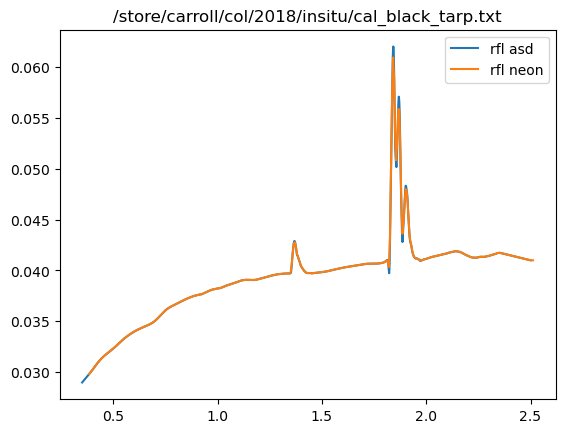

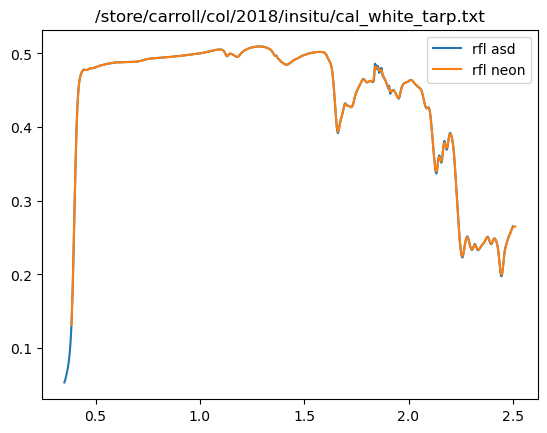

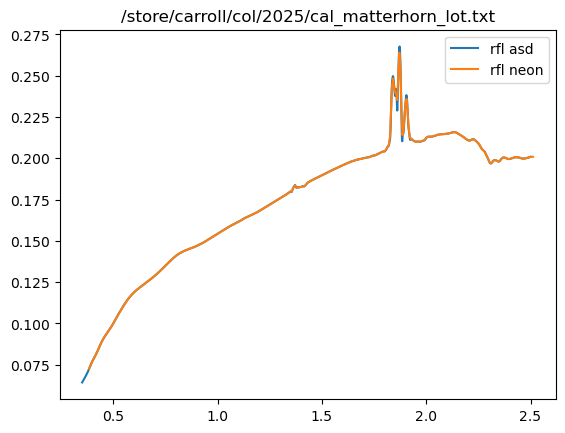

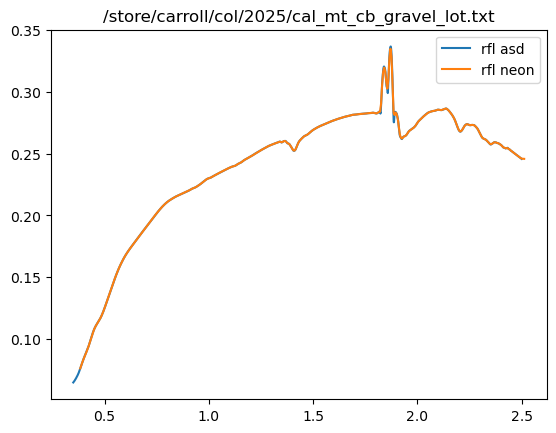

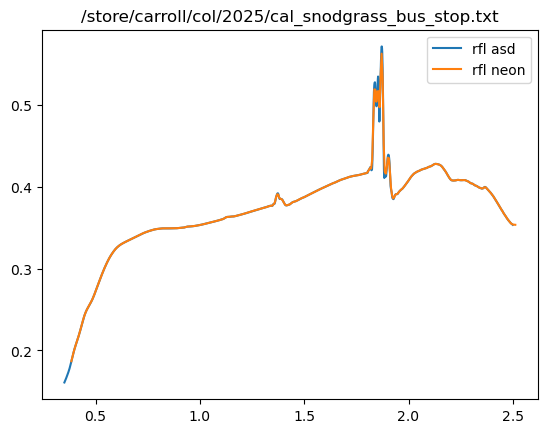

In [ ]:
fps = glob('/store/carroll/col/data/2018/insitu/cal*.txt', recursive=True)
fps = [x for x in fps if 'neon' not in x]

for fp in fps:
    rfl_asd = np.loadtxt(fp)[:,1]
    rfl_neon = np.zeros_like(wl_neon)
    for i, (center, fwhm) in enumerate(zip(wl_neon, fwhm_neon)):
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))  # Convert FWHM → Gaussian σ
        weights = np.exp(-0.5 * ((wl_asd - center) / sigma)**2)
        weights /= np.sum(weights)               # Normalize weights
        rfl_neon[i] = np.sum(rfl_asd * weights)     # Weighted average
    rfl_neon = np.stack([wl_neon, rfl_neon], axis=1)
    np.savetxt(fp.replace('.txt', '_neon.txt'), rfl_neon)

    fig = plt.figure()
    plt.plot(wl_asd, rfl_asd, label='rfl asd')
    plt.plot(wl_neon, rfl_neon[:,1], label='rfl neon')
    plt.title(fp)
    plt.legend()
    plt.show()

In [ ]:
# prepare isofit inputs for calibration tarps

In [ ]:
home = '/store/carroll/col/data/2018/'
cal = home+'raw/calibration_flights/' # calibration flights from Tristan
out = home+'rccs/'

buf = 25

# # # add byte order to all data
# fps = glob(cal + f'*/*.hdr')
# for fp in fps:
#     add_byte_order(fp)


 NIS01_20180611_172310


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.045466654..1.5].


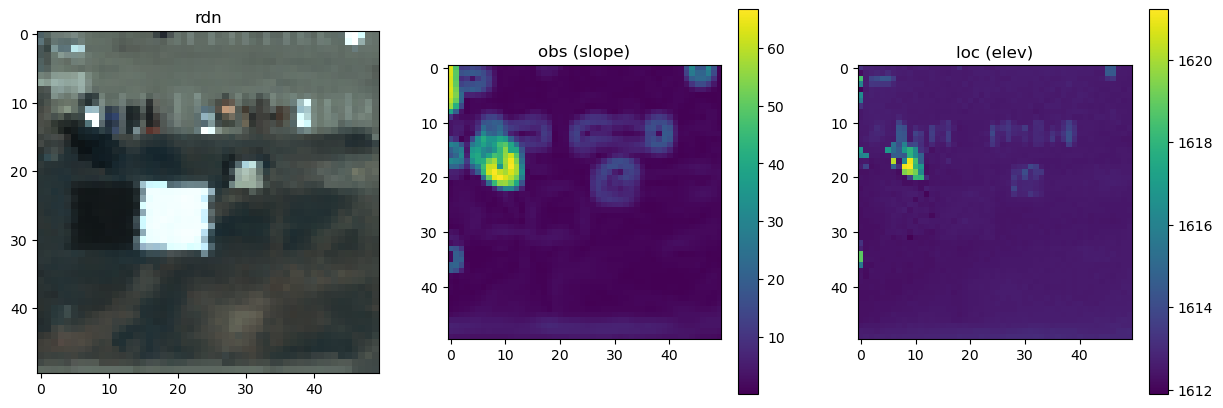


 NIS01_20180611_172711


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.045791857..1.5].


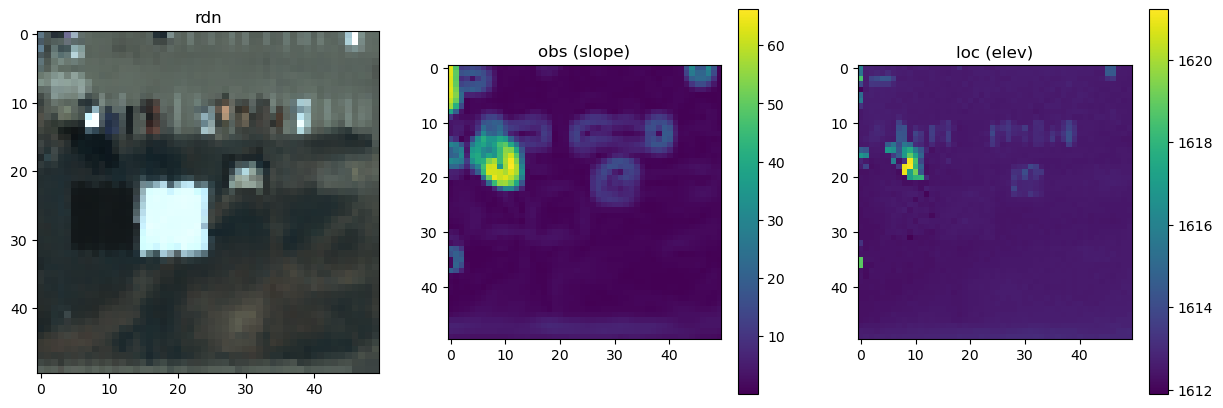


 NIS01_20180611_173116


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04809466..1.5].


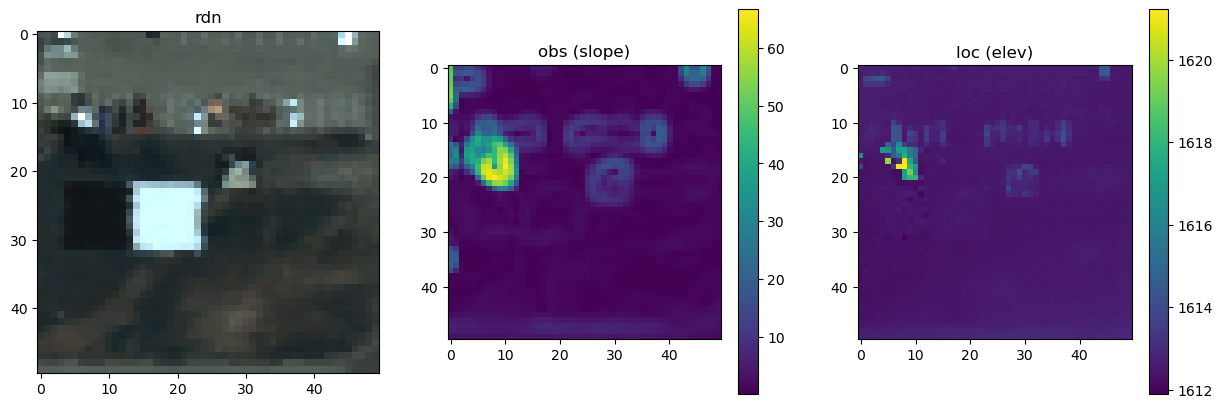


 NIS01_20180611_173537


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.043238934..1.5].


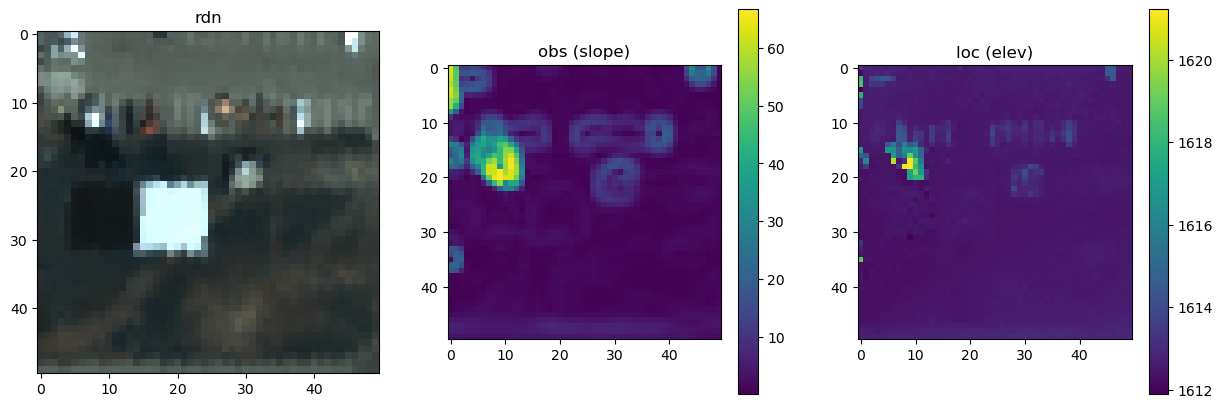

In [ ]:
# cal tarp

# Tristan email: Calibration tarps are located at 480273E, 4431900N
x, y = 480273, 4431900

output_dir = out+'calTarp/subset/'
os.makedirs(output_dir, exist_ok=True)

cal_flightlines = [x.split('/')[-1].strip('_rdn') for x in glob(cal + f'*/*_rdn')]

for flight in cal_flightlines:
    print('\n', flight)
    subset_region_ort(
        fp_rdn = cal+f'L1/{flight}_rdn_ort.hdr',
        fp_obs = cal+f'L1/{flight}_rdn_obs_ort.hdr',
        fp_igm = cal+f'L1/{flight}_rdn_ort_igm_ort.hdr',
        output_dir = output_dir,
        x = x,
        y = y,
        buf = buf,
        brighten_factor=1.5
    )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07828101..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.078737326..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.083023794..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07466234..2.0].


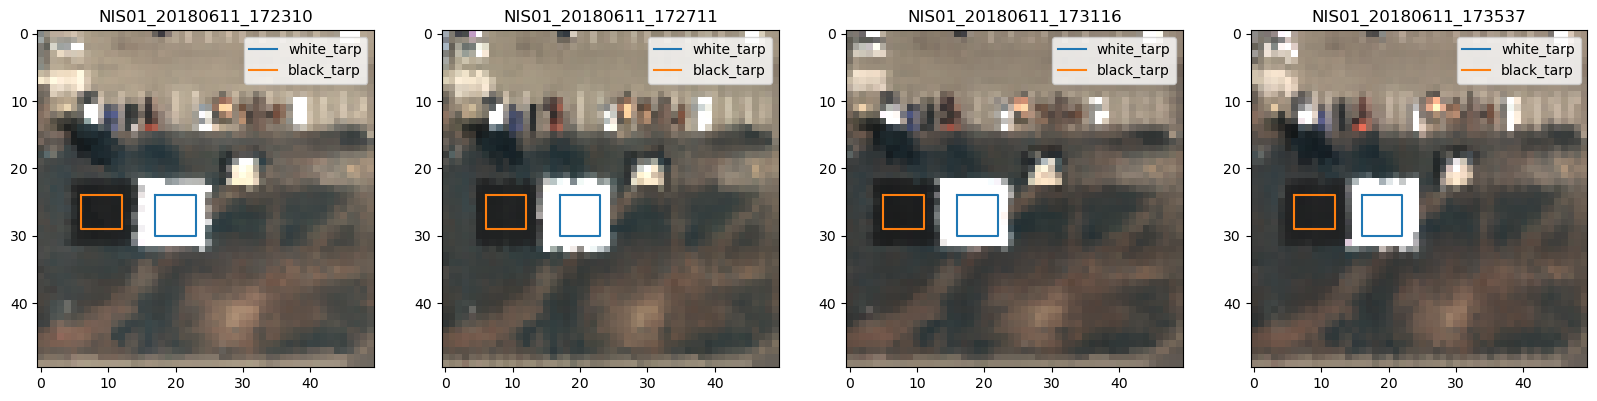

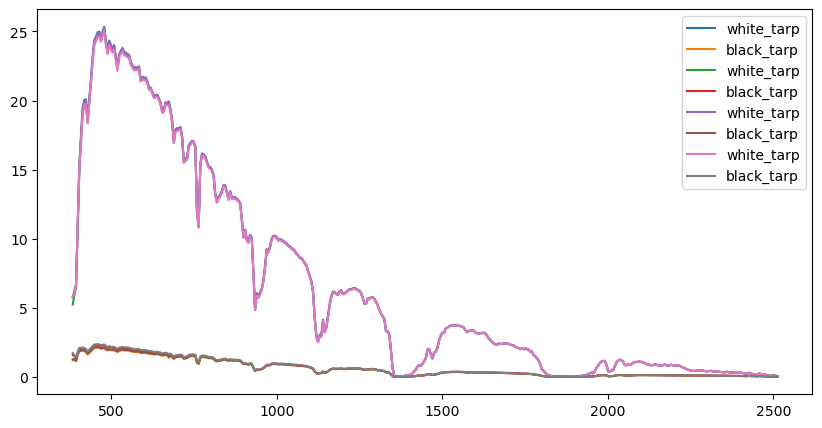

In [ ]:
# prepare representative single pixels

n_flights = len(cal_flightlines)
tarps = ['white_tarp', 'black_tarp']

# prepare representative single pixels
rdn = {k: {} for k in cal_flightlines}
obs = {k: {} for k in cal_flightlines}
loc = {k: {} for k in cal_flightlines}
bboxes = {k: {} for k in cal_flightlines}

# define bboxes per flightline
bboxes['NIS01_20180611_172310']['white_tarp'] = [17,24,23,30]
bboxes['NIS01_20180611_172310']['black_tarp'] = [6,24,12,29]

bboxes['NIS01_20180611_172711']['white_tarp'] = [17,24,23,30]
bboxes['NIS01_20180611_172711']['black_tarp'] = [6,24,12,29]

bboxes['NIS01_20180611_173116']['white_tarp'] = [16,24,22,30]
bboxes['NIS01_20180611_173116']['black_tarp'] = [5,24,11,29]

bboxes['NIS01_20180611_173537']['white_tarp'] = [16,24,22,30]
bboxes['NIS01_20180611_173537']['black_tarp'] = [6,24,12,29]

# cal tarps
fig, axs = plt.subplots(ncols=n_flights, figsize=(5*n_flights, 5))
for i in range(n_flights):
    flight = cal_flightlines[i]
    for k in tarps:
        minx, miny, maxx, maxy = bboxes[flight][k]
        fp = glob(os.path.join(cal, 'subset', f'{flight}_rdn.hdr'))[0]
        rdn[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
        fp = glob(os.path.join(cal, 'subset', f'{flight}_obs.hdr'))[0]
        obs[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
        fp = glob(os.path.join(cal, 'subset', f'{flight}_igm.hdr'))[0]
        loc[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    
    fp = glob(os.path.join(cal, 'subset', f'{flight}_rdn.hdr'))[0]
    wl = [float(x) for x in read_envi_header(fp)['wavelength']]
    rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
    for k, (minx, miny, maxx, maxy) in bboxes[flight].items():
        x = [minx, maxx, maxx, minx, minx]
        y = [miny, miny, maxy, maxy, miny]
        axs[i].plot(x, y, label=k)
    axs[i].legend()
    axs[i].set_title(flight)
plt.show()

# plot radiance

fig = plt.figure(figsize=(10,5))
for f in cal_flightlines:
    for k in ['white_tarp', 'black_tarp']:
        plt.plot(wl, rdn[f][k], label=k)
plt.legend()
plt.show()

In [ ]:
out = {
    'rdn':rdn,
    'obs':obs,
    'loc':loc,
    'bboxes': bboxes
}
with open('/store/carroll/col/2018/rccs/calTarp/single_pxs.pkl', 'wb') as f:
    pickle.dump(out, f)